In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
dataset = pd.read_csv('../data/datas.csv')

dataset.head()

,carimbo_tempo,nome,data_compromisso
0,15/04/2026 13:22:56,Victor Galvão,16/04
1,15/04/2026 13:22:56,Victor Galvão,04/05
2,15/04/2026 13:22:56,Victor Galvão,08/05
3,15/04/2026 13:22:56,Victor Galvão,11/05
4,15/04/2026 13:22:56,Victor Galvão,15/05


In [4]:
#transformando a coluna de datas em datetime
dataset['data_compromisso'] = pd.to_datetime(dataset['data_compromisso'], format='%d/%m')
dataset["data_compromisso"] = dataset["data_compromisso"].apply(lambda x: x.replace(year=2026) if pd.notnull(x) else x)

dataset.tail()

,carimbo_tempo,nome,data_compromisso
291,23/04/2026 16:55:45,Lívia,2026-06-23
292,23/04/2026 16:55:45,Lívia,2026-06-25
293,23/04/2026 16:55:45,Lívia,2026-06-29
294,23/04/2026 16:55:45,Lívia,2026-06-30
295,23/04/2026 16:55:45,Lívia,2026-07-01


In [5]:
#adicionar uma coluna para mês
dataset['mes'] = dataset['data_compromisso'].dt.month
#adicionar uma coluna para dia da semana
dataset['dia_semana'] = dataset['data_compromisso'].dt.day_name()

meses_nome = {
    1: 'Janeiro',
    2: 'Fevereiro',
    3: 'Março',
    4: 'Abril',
    5: 'Maio',
    6: 'Junho',
    7: 'Julho',
    8: 'Agosto',
    9: 'Setembro',
    10: 'Outubro',
    11: 'Novembro',
    12: 'Dezembro'
}

dataset['mes_nome'] = dataset['mes'].map(meses_nome)

dataset.tail()

,carimbo_tempo,nome,data_compromisso,mes,dia_semana,mes_nome
291,23/04/2026 16:55:45,Lívia,2026-06-23,6,Tuesday,Junho
292,23/04/2026 16:55:45,Lívia,2026-06-25,6,Thursday,Junho
293,23/04/2026 16:55:45,Lívia,2026-06-29,6,Monday,Junho
294,23/04/2026 16:55:45,Lívia,2026-06-30,6,Tuesday,Junho
295,23/04/2026 16:55:45,Lívia,2026-07-01,7,Wednesday,Julho


In [6]:
#dropar domingos
dataset = dataset[dataset['dia_semana'] != 'Sunday']
#dropar maio
dataset = dataset[dataset['mes'] != 4]

dataset.head()

,carimbo_tempo,nome,data_compromisso,mes,dia_semana,mes_nome
1,15/04/2026 13:22:56,Victor Galvão,2026-05-04,5,Monday,Maio
2,15/04/2026 13:22:56,Victor Galvão,2026-05-08,5,Friday,Maio
3,15/04/2026 13:22:56,Victor Galvão,2026-05-11,5,Monday,Maio
4,15/04/2026 13:22:56,Victor Galvão,2026-05-15,5,Friday,Maio
5,15/04/2026 13:22:56,Victor Galvão,2026-05-22,5,Friday,Maio


In [9]:
dataset['data_compromisso'] = pd.to_datetime(dataset['data_compromisso']).dt.normalize()

# --- ADICIONAR DIAS EXTRAS ---
datas_extras = []

# 01 de maio
datas_extras.append(pd.Timestamp('2026-05-01'))

# 06/07 até 31/07
datas_extras.extend(pd.date_range(start='2026-07-06', end='2026-07-31'))

# adicionar no dataset
dataset = pd.concat([
    dataset,
    pd.DataFrame({'data_compromisso': datas_extras})
], ignore_index=True)

# atualizar mês
dataset['mes'] = dataset['data_compromisso'].dt.month

<Axes: xlabel='mes'>

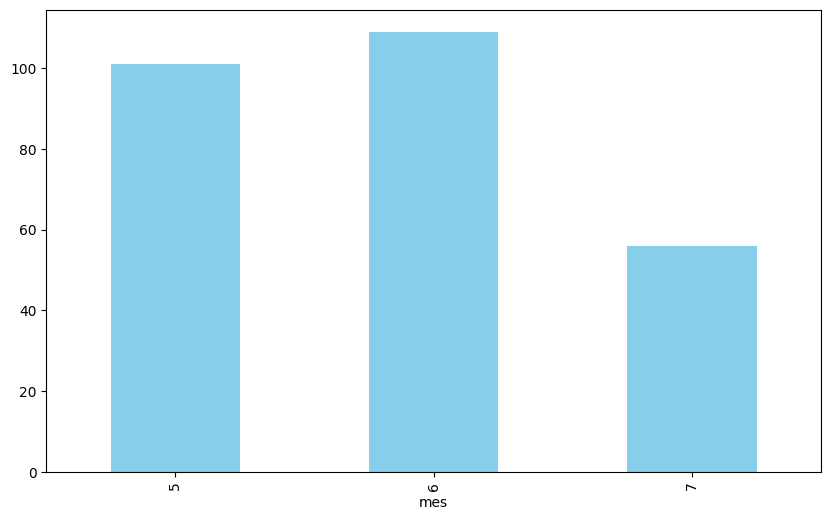

In [10]:
#analise por mes

compromissos_por_mes = dataset['mes'].value_counts()
compromissos_por_mes.sort_index(inplace=True)
plt.figure(figsize=(10, 6))
compromissos_por_mes.plot(kind='bar', color='skyblue')

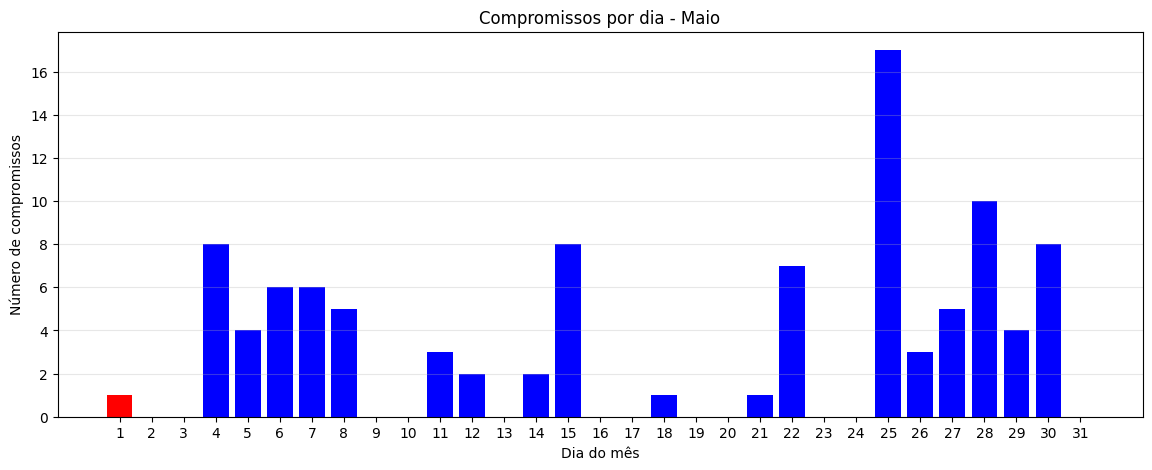

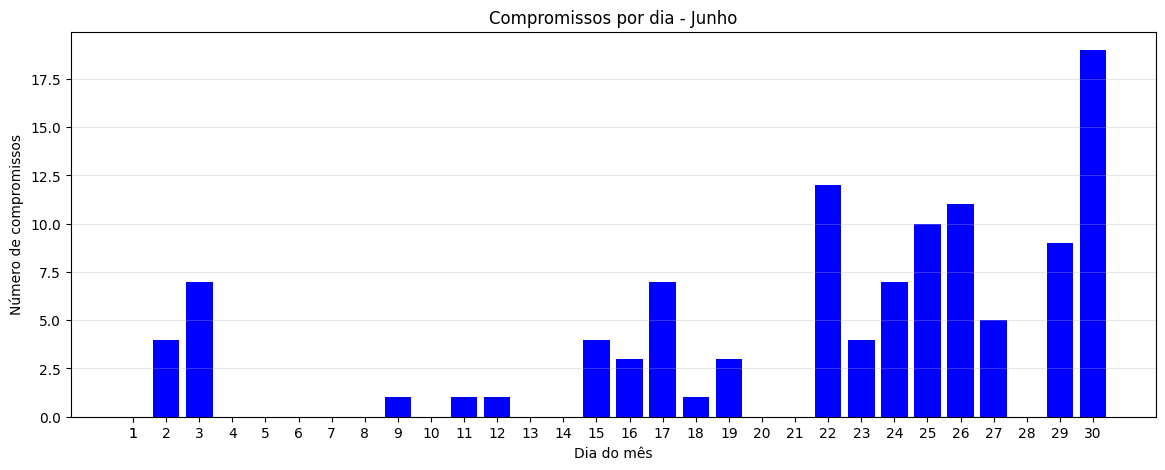

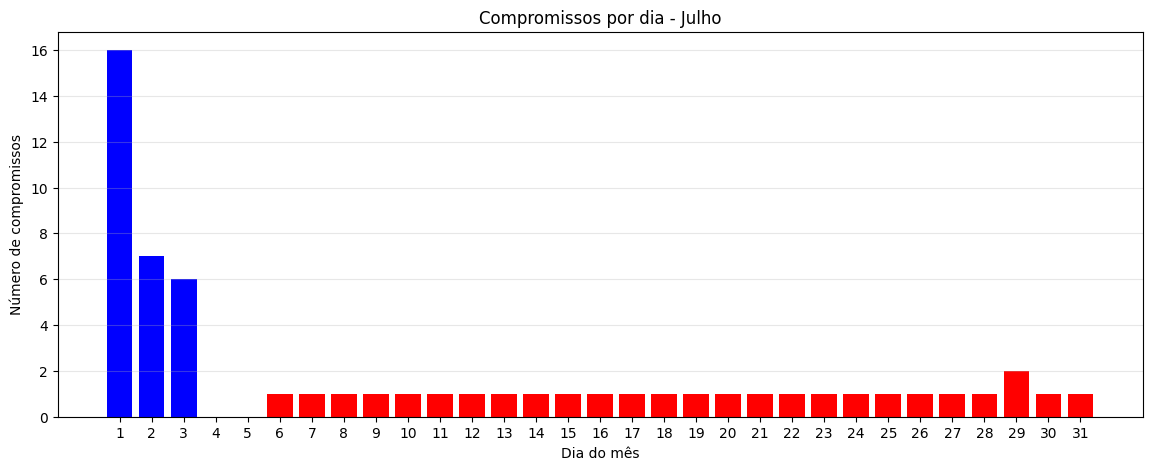

In [18]:
#verificar dias em um mes sem compromissos nos meses do dataset
for mes in dataset['mes'].unique():
    dataset['data_compromisso'] = pd.to_datetime(dataset['data_compromisso']).dt.normalize()
    dias_no_mes = pd.date_range(f'2026-{mes:02d}-01', periods=31, freq='D')

    compromissos_no_mes = dataset[dataset['mes'] == mes]['data_compromisso']

    dias_sem_compromissos = set(dias_no_mes) - set(compromissos_no_mes)

    contagem = []
    for dia in dias_no_mes:
        qtd = (compromissos_no_mes == dia).sum()
        contagem.append(qtd)

    plt.figure(figsize=(14, 5))
    cores = []
    for dia in dias_no_mes.day:
        if mes == 5 and dia == 1:
            cores.append("red")
        elif mes == 7 and dia > 5:
            cores.append("red")
        else:
            cores.append("blue")
    barras = plt.bar(dias_no_mes.day, contagem, color=cores)
    plt.title(f'Compromissos por dia - {meses_nome[mes]}')
    plt.xlabel('Dia do mês')
    plt.ylabel('Número de compromissos')
    plt.xticks(dias_no_mes.day)
    plt.grid(axis='y', alpha=0.3)

    plt.show()



In [17]:
#mostrar os dias para marcar reuniao com base nos dias sem compromissos
for mes in dataset['mes'].unique():
    dias_no_mes = pd.date_range(f'2026-{mes:02d}-01', periods=31, freq='D')
    dias_no_mes = dias_no_mes[dias_no_mes.month == mes]

    compromissos = pd.to_datetime(
        dataset[dataset['mes'] == mes]['data_compromisso']
    ).dt.normalize()

    dias_sem = set(dias_no_mes) - set(compromissos)

    lista = sorted(dias_sem)
    dataset_mes = pd.DataFrame(lista)
    dataset_mes.to_csv(f"../data/dias_livres_{mes}.csv")

    print(f"Mês: {meses_nome[mes]} - Dias sem compromissos: {[d.day for d in sorted(dias_sem)]}")



Mês: Maio - Dias sem compromissos: [2, 3, 9, 10, 13, 16, 17, 19, 20, 23, 24, 31]
Mês: Junho - Dias sem compromissos: [1, 4, 5, 6, 7, 8, 10, 13, 14, 20, 21, 28]
Mês: Julho - Dias sem compromissos: [4, 5]
